In [9]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

In [4]:
#diam*1000/650

def calcolo_pixel_diametro(diametro):
    return math.ceil(diametro * 1000 / 650)



In [5]:
def aggiungi_colonna_lato(csv_path):
    # Leggi il CSV
    df = pd.read_csv(csv_path)

    # Inizializza la nuova colonna
    lato= []

    # Itera su ogni riga del DataFrame
    for index, row in df.iterrows():
       # print(row['lat'], row['lon'])
        diam = row['diam']
       # print(y,x)
        ldiam= calcolo_pixel_diametro(diam)
        lato.append(ldiam)
      
    # Aggiungi le nuove colonne al DataFrame
    df['lato_bb'] = lato
        
    df.to_csv(csv_path, index=False)

    return df

In [6]:
for i in range(16):
    for j in range(64):
        csv_name=f'csv_sam/crateri_{i}_{j}.csv'
        aggiungi_colonna_lato(csv_name)
        print(f'fatto {i}_{j}')

fatto 0_0
fatto 0_1
fatto 0_2
fatto 0_3
fatto 0_4
fatto 0_5
fatto 0_6
fatto 0_7
fatto 0_8
fatto 0_9
fatto 0_10
fatto 0_11
fatto 0_12
fatto 0_13
fatto 0_14
fatto 0_15
fatto 0_16
fatto 0_17
fatto 0_18
fatto 0_19
fatto 0_20
fatto 0_21
fatto 0_22
fatto 0_23
fatto 0_24
fatto 0_25
fatto 0_26
fatto 0_27
fatto 0_28
fatto 0_29
fatto 0_30
fatto 0_31
fatto 0_32
fatto 0_33
fatto 0_34
fatto 0_35
fatto 0_36
fatto 0_37
fatto 0_38
fatto 0_39
fatto 0_40
fatto 0_41
fatto 0_42
fatto 0_43
fatto 0_44
fatto 0_45
fatto 0_46
fatto 0_47
fatto 0_48
fatto 0_49
fatto 0_50
fatto 0_51
fatto 0_52
fatto 0_53
fatto 0_54
fatto 0_55
fatto 0_56
fatto 0_57
fatto 0_58
fatto 0_59
fatto 0_60
fatto 0_61
fatto 0_62
fatto 0_63
fatto 1_0
fatto 1_1
fatto 1_2
fatto 1_3
fatto 1_4
fatto 1_5
fatto 1_6
fatto 1_7
fatto 1_8
fatto 1_9
fatto 1_10
fatto 1_11
fatto 1_12
fatto 1_13
fatto 1_14
fatto 1_15
fatto 1_16
fatto 1_17
fatto 1_18
fatto 1_19
fatto 1_20
fatto 1_21
fatto 1_22
fatto 1_23
fatto 1_24
fatto 1_25
fatto 1_26
fatto 1_27
fatto 1_

In [10]:
def generate_and_display_bounding_boxes(image_path, csv_path):
    # Carica l'immagine da image_path
    image = Image.open(image_path)

    # Carica i dati dal file CSV usando pandas
    df = pd.read_csv(csv_path)

    # Estrai colonne necessarie per le bounding box
    pixel_centers = list(zip(df['pixel_x'], df['pixel_y']))
    object_sizes = df['lato_bb'].tolist()

    # Inizializza la figura matplotlib per visualizzare l'immagine con le bounding box
    fig, ax = plt.subplots()
    ax.imshow(image)

    # Genera e disegna le bounding box
    bounding_boxes = []
    for center, size in zip(pixel_centers, object_sizes):
        half_size = size // 2
        x_min = max(0, center[0] - half_size)
        y_min = max(0, center[1] - half_size)
        x_max = min(image.size[0] - 1, center[0] + half_size)
        y_max = min(image.size[1] - 1, center[1] + half_size)

        # Creazione della bounding box come un rettangolo matplotlib
        rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                 linewidth=1, edgecolor='r', facecolor='none')
        ax.add_patch(rect)

        bounding_boxes.append((x_min, y_min, x_max, y_max))

    # Mostra l'immagine con le bounding box sovrapposte
    plt.show()

    return bounding_boxes

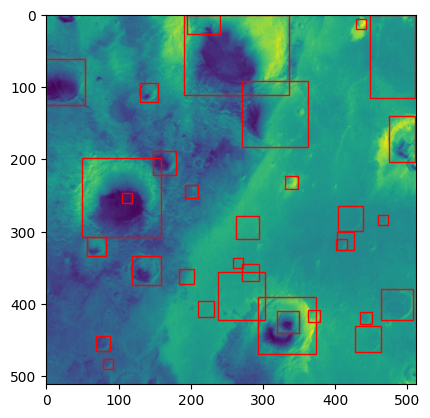

[(190, 0, 336, 111),
 (448, 0, 511, 115),
 (49, 198, 159, 308),
 (271, 91, 363, 183),
 (293, 390, 373, 470),
 (237, 356, 303, 422),
 (474, 140, 511, 204),
 (0, 61, 53, 125),
 (195, 0, 241, 26),
 (464, 379, 508, 423),
 (118, 334, 158, 374),
 (428, 431, 464, 467),
 (404, 265, 438, 299),
 (147, 189, 179, 221),
 (262, 278, 294, 310),
 (320, 410, 350, 440),
 (56, 308, 82, 334),
 (129, 94, 155, 120),
 (271, 345, 295, 369),
 (402, 301, 426, 325),
 (210, 396, 232, 418),
 (184, 352, 204, 372),
 (68, 445, 88, 465),
 (330, 223, 348, 241),
 (192, 235, 210, 253),
 (363, 409, 379, 425),
 (401, 310, 417, 326),
 (435, 412, 451, 428),
 (429, 5, 443, 19),
 (258, 336, 272, 350),
 (78, 477, 92, 491),
 (459, 277, 473, 291),
 (104, 247, 118, 261)]

In [12]:
generate_and_display_bounding_boxes('immagini_sam/immagine_6_29.png','csv_sam/crateri_6_29.csv')